# <font color='steelblue'> Otros métodos de componentes principales</font>

**Material desarrollado por los [equipos de trabajo de IA4LEGOS](https://ia4legos.umh.es/)**


**Fecha última edición**: 03/06/2026

**Licencia**: <small><a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-sa/4.0/88x31.png" /></a><br /></small>

No olvides hacer una copia si deseas utilizarlo. Al usar estos contenidos, aceptas nuestros términos de uso y nuestra política de privacidad.

## <font color="steelblue">Descripción y Configuración del cuaderno</font>

**Descripción:** En este cuaderno exploramos otros métodos de componentes princiaples

In [1]:
# @title Cargar configuración del cuaderno
!pip install gdown
!pip install --upgrade kagglehub
!pip install lightgbm xgboost
!pip install ucimlrepo

# Análisis numérico
import numpy as np
import pandas as pd
import math, random
import warnings
warnings.filterwarnings('ignore')

# Gráficos
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_theme(style='whitegrid')
%config InlineBackend.figure_format = 'retina'

import os, zipfile, gdown, kagglehub

# Funciones del curso
from urllib.request import urlretrieve
for fichero in ['preprocesar.py', 'evaluar_clasificadores.py', 'pca_funciones.py', 'auto_ML.py']:
    urlretrieve(f'https://raw.githubusercontent.com/ia4legos/MachineLearning/refs/heads/main/{fichero}', fichero)
from preprocesar import *
from evaluar_clasificadores import *
from pca_funciones import *
from auto_ML import *


# <font color="steelblue">1. Introducción</font>

Imagina que tienes que fotografiar una escultura para describirla en una sola foto. Te moverás hasta encontrar el ángulo que mejor la "cuenta": el que conserva más detalle reconocible en la imagen plana. Eso es, en esencia, lo que hace el **PCA**: busca el "ángulo" (la combinación de variables) desde el que los datos, al proyectarse sobre menos dimensiones, conservan la mayor cantidad de información posible —y esa "información" se mide como **varianza**.

Formalmente, sobre los datos centrados $X$ ($n$ muestras × $p$ variables) se calcula la SVD $X = U\Sigma V^{\top}$; las componentes principales son las columnas de $V$ y las coordenadas proyectadas son $XV_k = U_k\Sigma_k$. Es un método exacto, elegante e interpretable. Pero tiene tres "puntos ciegos" que, con los años, han hecho nacer variantes especializadas:

1. **Se atraganta con datos enormes.** La SVD exacta cuesta $O(n_{\max}^2 n_{\min})$ y necesita todos los datos en memoria a la vez.
2. **Solo ve líneas rectas.** Si la estructura de los datos está "enrollada" de forma curva, los ejes rectos de la PCA no la capturan.
3. **Ordena, pero no separa voces.** Deja las componentes sin correlación, lo que solo equivale a independencia si los datos son gaussianos.

Cada variante de esta ficha cura uno de esos puntos ciegos:

| Punto ciego de la PCA | Variante que lo cura |
|---|---|
| Se atraganta con datos enormes | PCA **aleatorizada** y PCA **incremental** |
| Solo ve líneas rectas | **Kernel PCA** |
| No separa "voces" mezcladas | **FastICA** (ICA) |

A lo largo de las secciones 2–5 desarrollamos cada variante con la misma estructura —una **intuición** con analogía cotidiana, el **cómo funciona por dentro** y un balance de **ventajas y desventajas**—; la sección 6 las resume en una tabla y la sección 7 las pone a prueba sobre datos reales. Conviene leer cada método teniendo en mente la pregunta práctica que responde: *¿mis datos son demasiado grandes?, ¿su estructura es curva?, ¿quiero comprimir o separar señales?*


# 2. PCA aleatorizada


## 2.1. La intuición

Para conocer la intención de voto de un país no hace falta preguntar a sus 40 millones de habitantes: con una **muestra aleatoria** bien tomada de unas miles de personas se estima el resultado con un error mínimo. La PCA aleatorizada usa exactamente esta idea, pero con direcciones del espacio en lugar de votantes: en vez de explorar minuciosamente todas las direcciones posibles, lanza unas pocas **sondas aleatorias** que, por pura estadística, "iluminan" las direcciones donde se concentra la información. Y como casi siempre solo queremos las primeras $k$ componentes (con $k$ muy pequeño frente al total), explorar el resto sería tirar trabajo.

## 2.2. Cómo funciona por dentro

La **SVD aleatorizada** lo hace en tres fases:

* **Buscar el "barrio" correcto (*range finder*).** Queremos una base ortonormal $Q$ que capture el subespacio donde vive la mayor parte de la varianza. Se multiplica $X$ por una matriz aleatoria gaussiana $\Omega$:
$$Y = X\Omega, \qquad Q = \text{ortonormaliza}(Y).$$
Cada columna de $Y$ es una mezcla aleatoria de las columnas de $X$; con muy alta probabilidad, unas pocas mezclas bastan para encontrar el "barrio" donde están las direcciones importantes. Se añaden unas columnas de más —el **sobremuestreo** `n_oversamples` (10 por defecto)— como red de seguridad: mejoran mucho la precisión a coste casi nulo.

* **Afinar el enfoque (iteraciones de potencia).** Si las direcciones importantes no destacan claramente (el espectro decae despacio), se repite la sonda elevando la matriz a una potencia: $Y = (XX^{\top})^{q}X\Omega$ (parámetro `n_iter`). Es como subir el contraste de una foto para que lo relevante resalte sobre el ruido.

* **Hacer el trabajo fino, pero en pequeño.** Se proyecta $X$ sobre el barrio hallado, $B = Q^{\top}X$ (una matriz ya diminuta), y sobre ella se hace la SVD **exacta**. Como $B$ es pequeña, este último paso es barato.

El resultado: el coste baja de $O(n_{\max}^2 n_{\min})$ a $O(n_{\max}^2 k)$ y, en la práctica, las componentes salen **indistinguibles de las exactas** cuando el espectro decae (lo habitual). Como interviene el azar, conviene fijar `random_state` para que el experimento sea reproducible.

## 2.3. Ventajas y desventajas frente a la PCA lineal

| | PCA aleatorizada |
|---|---|
| ✅ | Mucho **más rápida y ligera** si $k \ll \min(n,p)$; conserva **toda la interpretación** de la PCA (componentes ortogonales, `explained_variance_ratio_`, *loadings*); resultado casi idéntico al exacto. |
| ⚠️ | Es **aproximada y depende del azar** (hay que fijar la semilla); no aporta nada si necesitas todas las componentes o si el dataset es pequeño; el `inverse_transform` no es exacto. |

# 3. Kernel PCA


## 3.1. La intuición

Dibuja dos anillos, uno dentro del otro, en una hoja de papel. Por más que gires la hoja, **no hay ninguna línea recta** que deje un anillo a un lado y el otro al otro: están "enrollados". Ahora levanta el anillo interior fuera del papel, hacia ti: visto desde el lado, ¡ahora sí puedes separarlos con un plano! Ese "levantar a una dimensión extra donde lo curvo se vuelve recto" es justo lo que hace la **Kernel PCA**. Lo asombroso es que lo consigue **sin construir nunca esa dimensión extra**, mediante un atajo matemático llamado *truco del kernel*.

## 3.2. Cómo funciona por dentro

La PCA lineal diagonaliza la covarianza $C = \frac{1}{n}X^{\top}X$ ($p\times p$). La Kernel PCA querría hacer PCA tras un mapeo no lineal $\phi: x \mapsto \phi(x)$ que "levanta" los datos a un espacio $\mathcal{F}$, pero ese espacio puede ser de dimensión enorme (o infinita). El truco: toda la PCA puede reescribirse usando **solo productos escalares**, y el producto escalar en $\mathcal{F}$ es precisamente un **kernel**, que sí sabemos calcular barato:
$$K(x_i, x_j) = \langle \phi(x_i), \phi(x_j)\rangle.$$

Así, en vez de la covarianza, se trabaja con la **matriz de Gram** $K \in \mathbb{R}^{n\times n}$. Como la PCA exige datos centrados (y en $\mathcal{F}$ no podemos restar la media a mano), se **centra la propia matriz de Gram** con la fórmula del doble centrado:
$$\tilde{K} = K - \mathbf{1}_n K - K\mathbf{1}_n + \mathbf{1}_n K \mathbf{1}_n,\qquad \mathbf{1}_n = \tfrac{1}{n}\mathbf{1}\mathbf{1}^{\top}.$$

Se resuelve el problema de autovalores $\tilde{K}\,\alpha = n\lambda\,\alpha$, y la proyección de un punto sobre la $l$-ésima componente no lineal se calcula combinando sus kernels con todos los puntos de entrenamiento:
$$\text{proy}_l(x) = \sum_{i=1}^{n} \alpha_i^{(l)}\, K(x_i, x).$$

**Kernels habituales** (parámetro `kernel`): `rbf` (gaussiano, $K=\exp(-\gamma\lVert x-x'\rVert^2)$, el más usado), `poly`, `sigmoid`, `cosine`. El hiperparámetro **`gamma`** del RBF regula cuánto "se nota" cada punto: pensar en la "anchura del foco". Muy grande, cada punto se aísla en su propia islita (sobreajuste); muy pequeño, todo se difumina en una masa indistinta (subajuste). Por eso conviene **ajustarlo** —en el ejemplo veremos que `gamma=2` separa perfectamente y `gamma=15` ya estropea el resultado.

## 3.3. Ventajas y desventajas frente a la PCA lineal

| | Kernel PCA |
|---|---|
| ✅ | Capta **estructura no lineal**: separa o "desenrolla" lo que la PCA lineal no puede; sirve para preprocesar antes de clasificar, para **eliminar ruido** (*denoising*) y para reconstrucción no lineal. |
| ⚠️ | Hay que **elegir kernel e hiperparámetros**; la matriz de Gram es $n\times n$, así que **crece con el nº de muestras** ($O(n^3)$ exacto, aliviable con `eigen_solver='randomized'`); las componentes **no se interpretan** como combinación de las variables originales; el `inverse_transform` es **aproximado** (el "problema de la pre-imagen"); el nº de componentes está limitado por $n_{\text{muestras}}$. |


# 4. PCA incremental

## 4.1. La intuición

¿Cómo resumes un libro de 2000 páginas si no te cabe entero en la cabeza? No lo memorizas de golpe: lo lees **capítulo a capítulo** y vas actualizando un resumen que llevas aparte. Al terminar, tu resumen recoge lo esencial de todo el libro sin haber tenido nunca las 2000 páginas en la memoria a la vez. La **PCA incremental** hace lo mismo con los datos: los procesa por **mini-lotes** y va refinando su estimación de las componentes, sin necesidad de cargarlo todo en RAM.

## 4.2. Cómo funciona por dentro

La PCA exacta es **batch**: necesita todo $X$ en memoria. La incremental mantiene una estimación de las primeras $k$ componentes y de sus varianzas, y la **actualiza con cada lote nuevo** sin volver a mirar los anteriores. Conceptualmente, fusiona el resumen acumulado con la SVD del lote recién llegado (una actualización de rango bajo) y vuelve a quedarse con las $k$ direcciones principales. Como solo necesita tener en memoria un lote cada vez, permite hacer PCA **fuera de núcleo** (*out-of-core*): alimentando lotes con `partial_fit` desde disco o red, o trabajando sobre un fichero `numpy.memmap`. El resumen final **casi coincide** con el de la PCA exacta.

### 4.3. Ventajas y desventajas frente a la PCA incremental

| | PCA incremental |
|---|---|
| ✅ | **Memoria constante** (la fija el tamaño del lote) → permite datasets **más grandes que la RAM** y aprendizaje en *streaming*; resultado casi idéntico al exacto y con la misma interpretación. |
| ⚠️ | Algo **menos precisa**; hay que elegir un `batch_size` razonable (≥ `n_components`); si los datos **sí caben** en memoria, suele ser **más lenta** que una única SVD en bloque; y sigue siendo **lineal**. |

# 5. FastICA


## 5.1. La intuición

Estás en una fiesta. Tres personas hablan a la vez y tienes tres micrófonos repartidos por la sala; cada micrófono capta una **mezcla** distinta de las tres voces. ¿Se puede, solo con esas grabaciones mezcladas, reconstruir cada voz por separado? Sorprendentemente, sí: es el **problema del cóctel**, y el ICA lo resuelve. La PCA, en cambio, solo "ordena la sala" (deja las señales sin correlación) pero no recupera las voces individuales. Esa es la diferencia de fondo: **PCA decorrelaciona; ICA independiza.**

## 5.2. Cómo funciona por dentro

El ICA supone que lo observado es una **mezcla lineal de fuentes independientes**: $X = S A^{\top}$, con $S$ las fuentes (las "voces") y $A$ la matriz de mezcla, ambas desconocidas. Busca una matriz de des-mezcla $W$ tal que $\hat S = XW$ recupere las fuentes.

¿Por qué se puede? Por una pista estadística preciosa: el **Teorema del Límite Central** dice que sumar variables independientes tiende a producir algo **más gaussiano** (más con forma de campana) que los ingredientes originales. Luego, si una mezcla es "más campana" que sus fuentes, para des-mezclar basta buscar las direcciones que hacen las proyecciones **lo menos gaussianas posibles**. FastICA mide esa no-gaussianidad con la **negentropía**, aproximada con funciones de contraste $G$ (las típicas: `logcosh`, $G(u)=\log\cosh u$, y `exp`, $G(u)=-e^{-u^2/2}$), y la maximiza con una iteración de **punto fijo** muy veloz —de ahí lo de "Fast":
$$w^{+} = \mathbb{E}[x\,g(w^{\top}x)] - \mathbb{E}[g'(w^{\top}x)]\,w,\qquad w \leftarrow w^{+}/\lVert w^{+}\rVert,$$
con $g = G'$.

**Un requisito: blanquear primero (*whitening*).** Como el modelo no contempla ruido, antes hay que decorrelacionar y normalizar las varianzas de los datos (internamente, con una PCA). Por eso ICA suele ir **después** de una PCA: la PCA reduce y ordena, e ICA independiza.

**Tres cosas que ICA no puede saber:** el **orden**, el **signo** y la **escala** de las fuentes. Recupera *la forma* de cada voz, pero no cuál venía "primera" ni a qué volumen. No existe, por tanto, una "primera componente" como en la PCA.

### 5.3. Ventajas y desventajas frente a la PCA lineal

| | FastICA |
|---|---|
| ✅ | **Recupera fuentes independientes** que la PCA no separa (audio, EEG/MEG, señales mezcladas); saca a la luz factores **no gaussianos** con sentido físico; produce representaciones **localizadas/dispersas** (p. ej., rasgos faciales concretos). |
| ⚠️ | **No es un método de reducción por varianza** (no ordena ni comprime); asume fuentes **independientes y no gaussianas** y **sin ruido**; las componentes salen **sin orden, signo ni escala** fijos; es sensible al blanqueo; y **no** puede separar fuentes gaussianas. |

# 6. Tabla comparativa

| Método | Para qué sirve | Lineal | Coste/memoria | Reemplaza a la PCA cuando… |
|---|---|:---:|---|---|
| PCA exacta | Reducir por varianza | Sí | $O(n_{\max}^2 n_{\min})$, todo en RAM | — (referencia) |
| PCA aleatorizada | La misma PCA, más rápida | Sí | $O(n_{\max}^2 k)$ | Datos grandes/anchos y pocas componentes |
| Kernel PCA | Capturar lo no lineal | No | $\sim O(n^2k)$–$O(n^3)$ | El "manifold" es curvo; las clases no se separan con rectas |
| PCA incremental | PCA sin cargarlo todo | Sí | $\propto$ tamaño del lote | No cabe en RAM o llega en *streaming* |
| FastICA | Separar señales mezcladas | Mezcla lineal | Moderado | El objetivo es separar fuentes, no comprimir |

# 7. Soluciones prácticas

A continuación presentamos diferentes ejemplos de uso de estos métodos. Comenzamos preparando el entorno:

In [2]:
import time
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles, fetch_olivetti_faces, load_digits
from sklearn.decomposition import PCA, KernelPCA, IncrementalPCA, FastICA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

RNG = 42

## 7.1. Círculos concéntricos — Kernel PCA frente a PCA lineal

Es el "experimento de los dos anillos" de la intuición: la PCA lineal no consigue separarlos; la Kernel PCA sí.

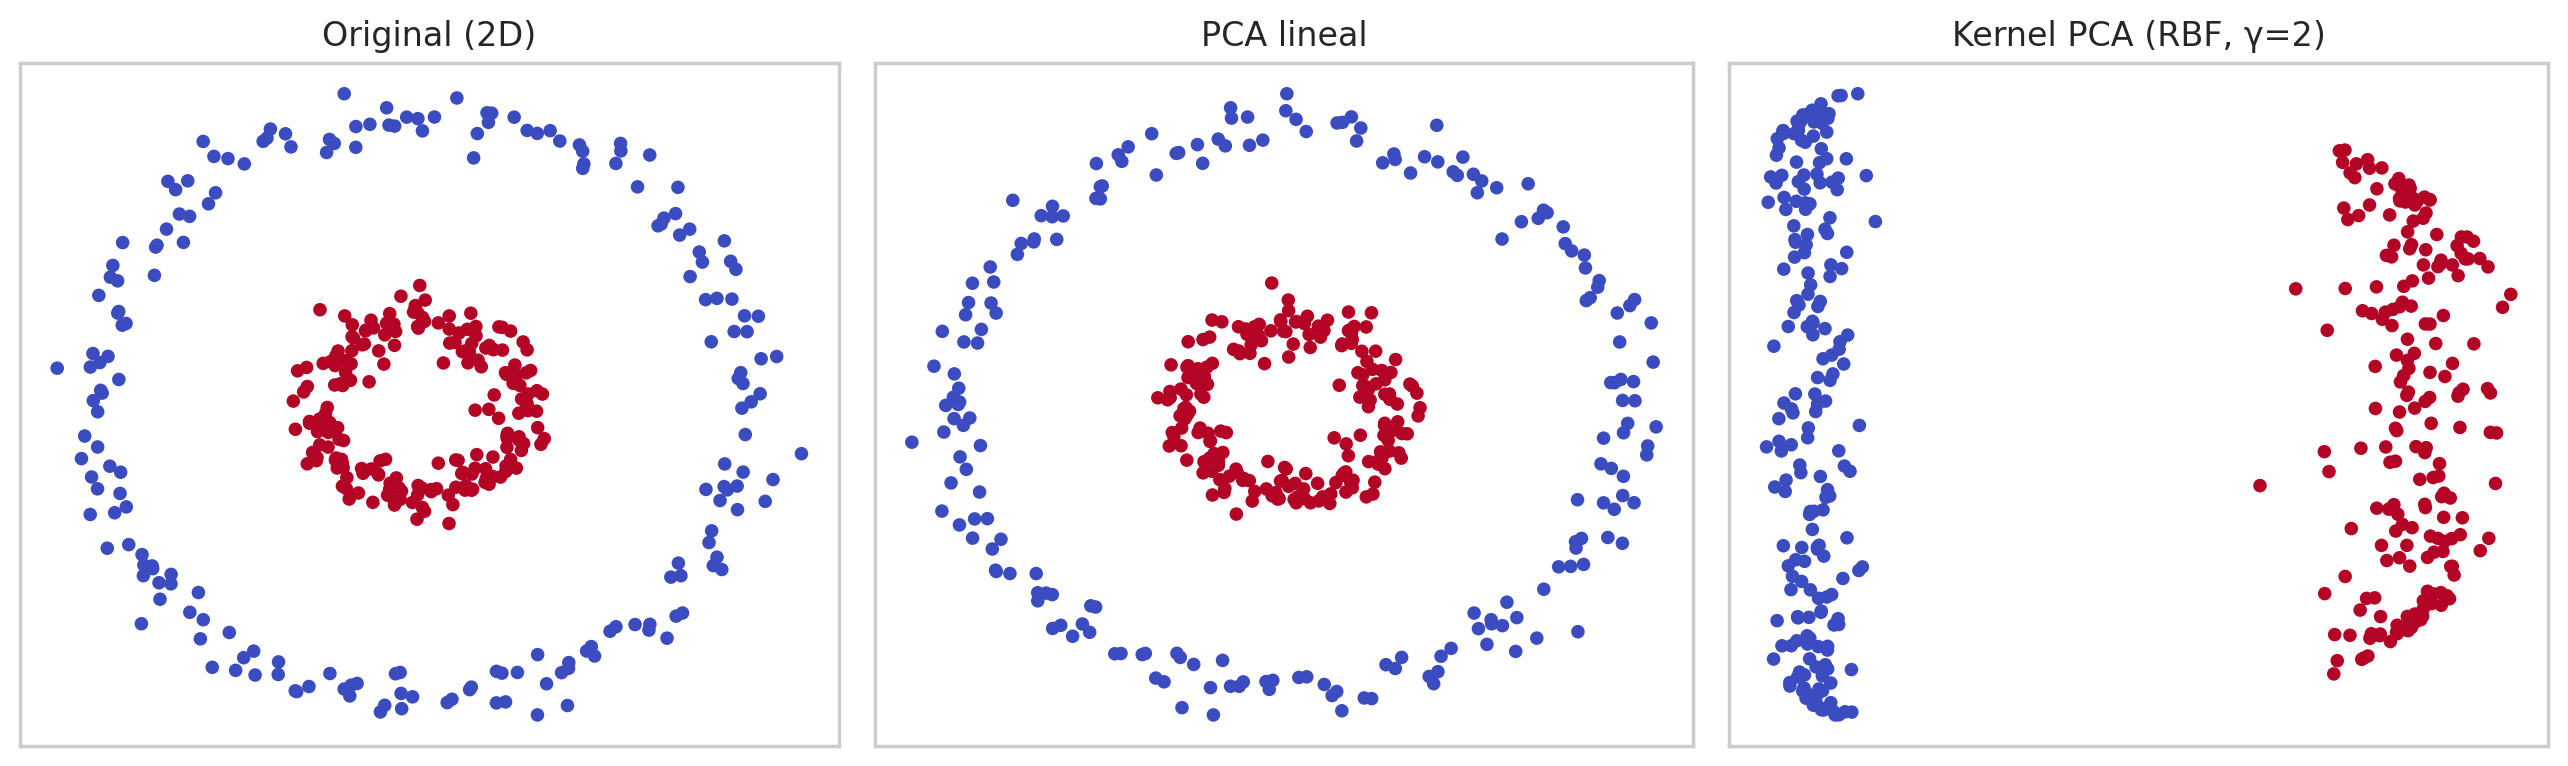

In [3]:
Xc, yc = make_circles(n_samples=400, factor=0.3, noise=0.05, random_state=RNG)

pca   = PCA(n_components=2, random_state=RNG).fit_transform(Xc)
kpca  = KernelPCA(n_components=2, kernel='rbf', gamma=2, random_state=RNG).fit_transform(Xc)

# Visualización
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].scatter(*Xc.T,   c=yc, cmap='coolwarm', s=15); ax[0].set_title('Original (2D)')
ax[1].scatter(*pca.T,  c=yc, cmap='coolwarm', s=15); ax[1].set_title('PCA lineal')
ax[2].scatter(*kpca.T, c=yc, cmap='coolwarm', s=15); ax[2].set_title('Kernel PCA (RBF, γ=2)')
for a in ax: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

**Lectura del resultado.** Los tres paneles cuentan la historia de un vistazo:

- **Original (2D)** y **PCA lineal** son prácticamente idénticos: la PCA solo ha *rotado y reescalado* el plano (busca las direcciones de máxima varianza), pero los dos anillos siguen uno **dentro** del otro. Por mucho que giremos esa imagen, **ninguna recta** deja el anillo azul a un lado y el rojo al otro: son linealmente inseparables. La PCA, al ser lineal, no puede deshacer una estructura curva.
- **Kernel PCA (RBF, γ=2)** transforma el problema: en el nuevo espacio los dos anillos se han convertido en **dos franjas verticales bien separadas** (azul a la izquierda, rojo a la derecha). Ahora **sí** basta una línea vertical para separarlos perfectamente. El *truco del kernel* ha "desenrollado" lo que era circular.

Cuando la frontera entre clases es curva, proyectar con Kernel PCA *antes* de clasificar puede convertir un problema imposible para un modelo lineal en uno trivial. Eso sí, todo depende de elegir bien `gamma`.

> **Nota didáctica sobre `gamma`:** con `gamma=2` la separación es perfecta; con `gamma=15` cae a ~0.76. El kernel RBF es muy sensible a `gamma`, así que en un caso real conviene ajustarlo por validación cruzada (`GridSearchCV` sobre un `Pipeline` KernelPCA → clasificador).

## 7.2. Caras de Olivetti — aleatorizada, incremental e ICA


Dataset de **alta dimensión** (400 imágenes × 4096 píxeles), perfecto para ver el resto de variantes en acción. Representamos las primeras 18 imágenes del banco de datos

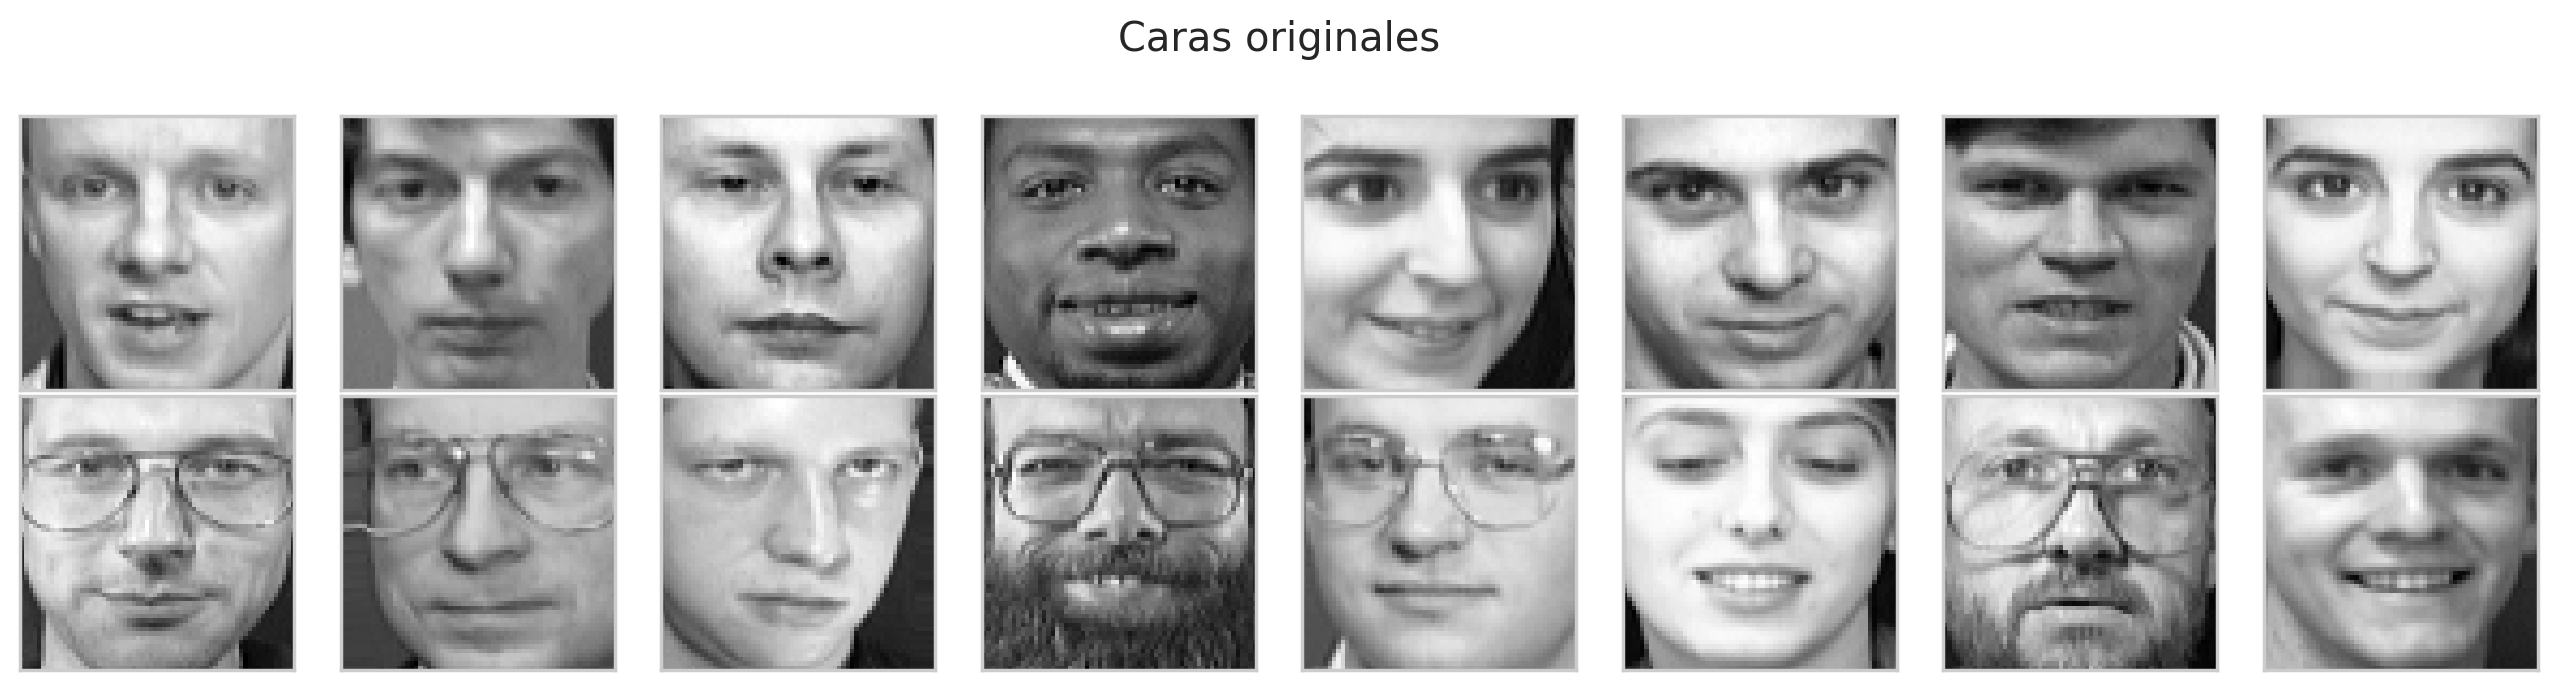

In [8]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA, FastICA

faces = fetch_olivetti_faces(shuffle=True, random_state=RNG)
X = faces.data

# Función para representar las imágenes
def galeria(componentes, titulo):
    fig, ax = plt.subplots(2, 8, figsize=(13, 3.5))
    for i, a in enumerate(ax.ravel()):
        a.imshow(componentes[i].reshape(64, 64), cmap='gray')
        a.set_xticks([]); a.set_yticks([])
    fig.suptitle(titulo); plt.tight_layout(); plt.show()

# Primeras 16 imágenes
galeria(X[:n_comp], 'Caras originales')

Veamos la solución para las primeras 16 componentes tanto en el algortimo PCA como PCa incremental y FastICA.

Tiempo exacta=650 ms | aleatorizada=490 ms
Máx. diferencia en varianza explicada: 5.70e-07
Var. explicada  exacta=0.7310 | incremental=0.7248


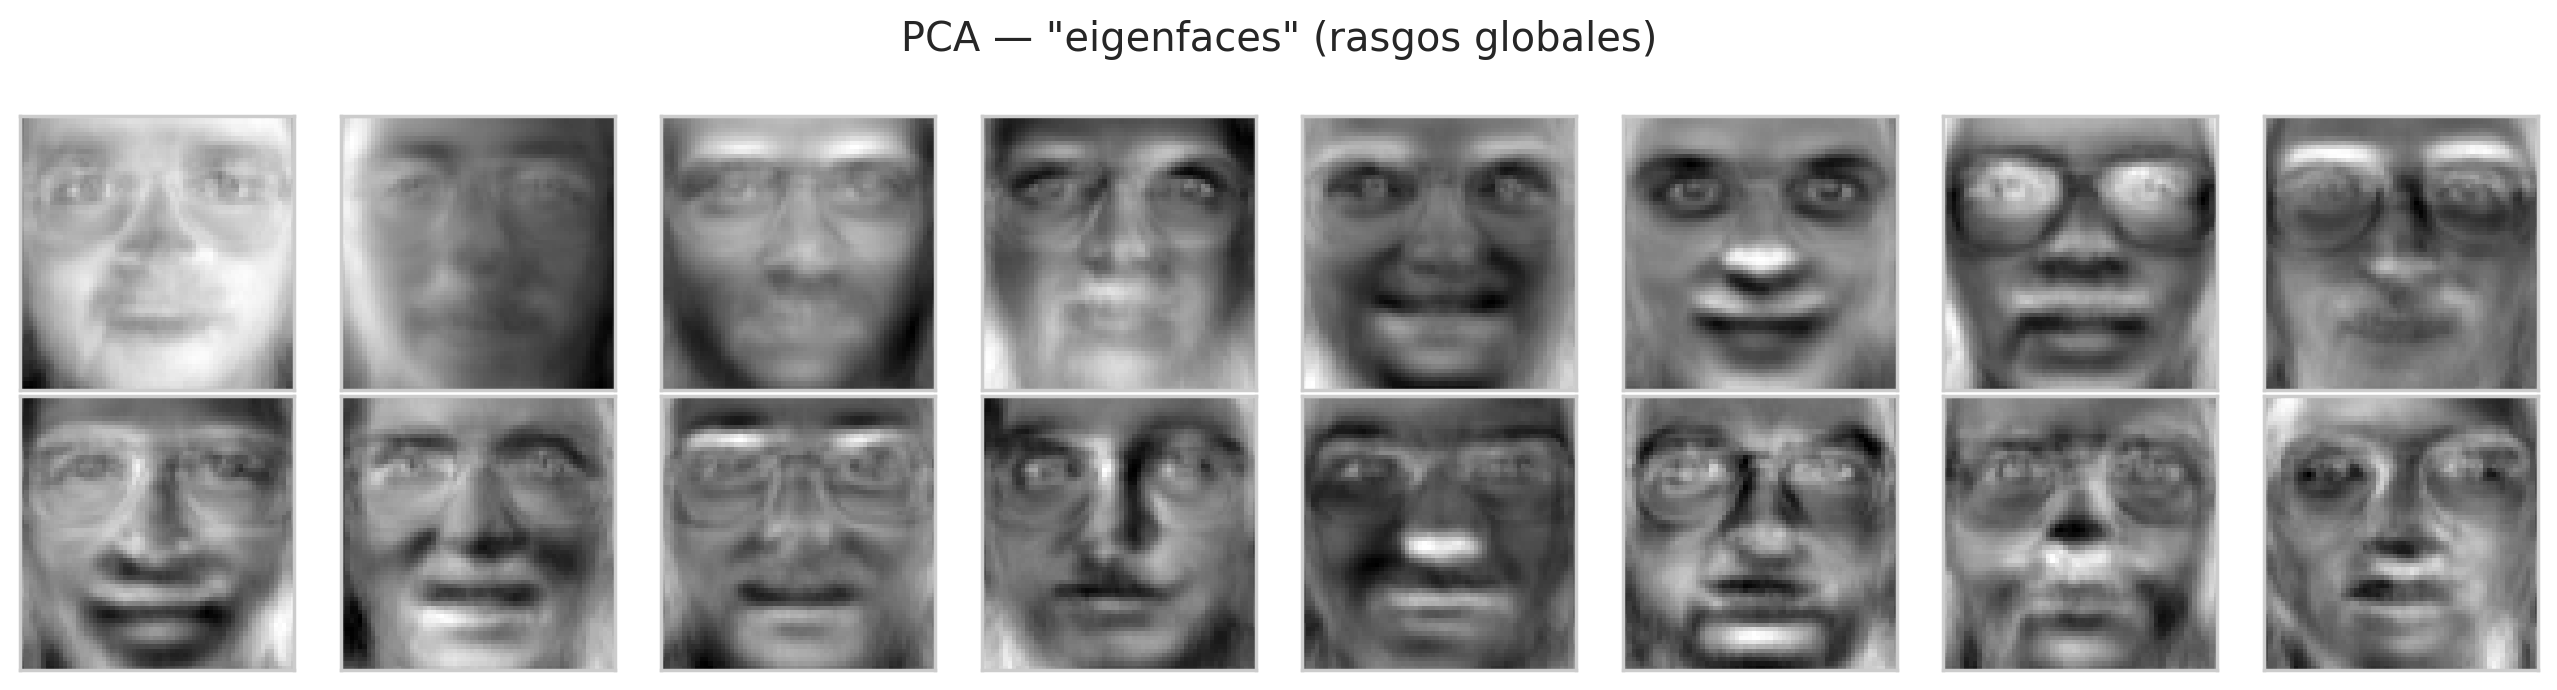

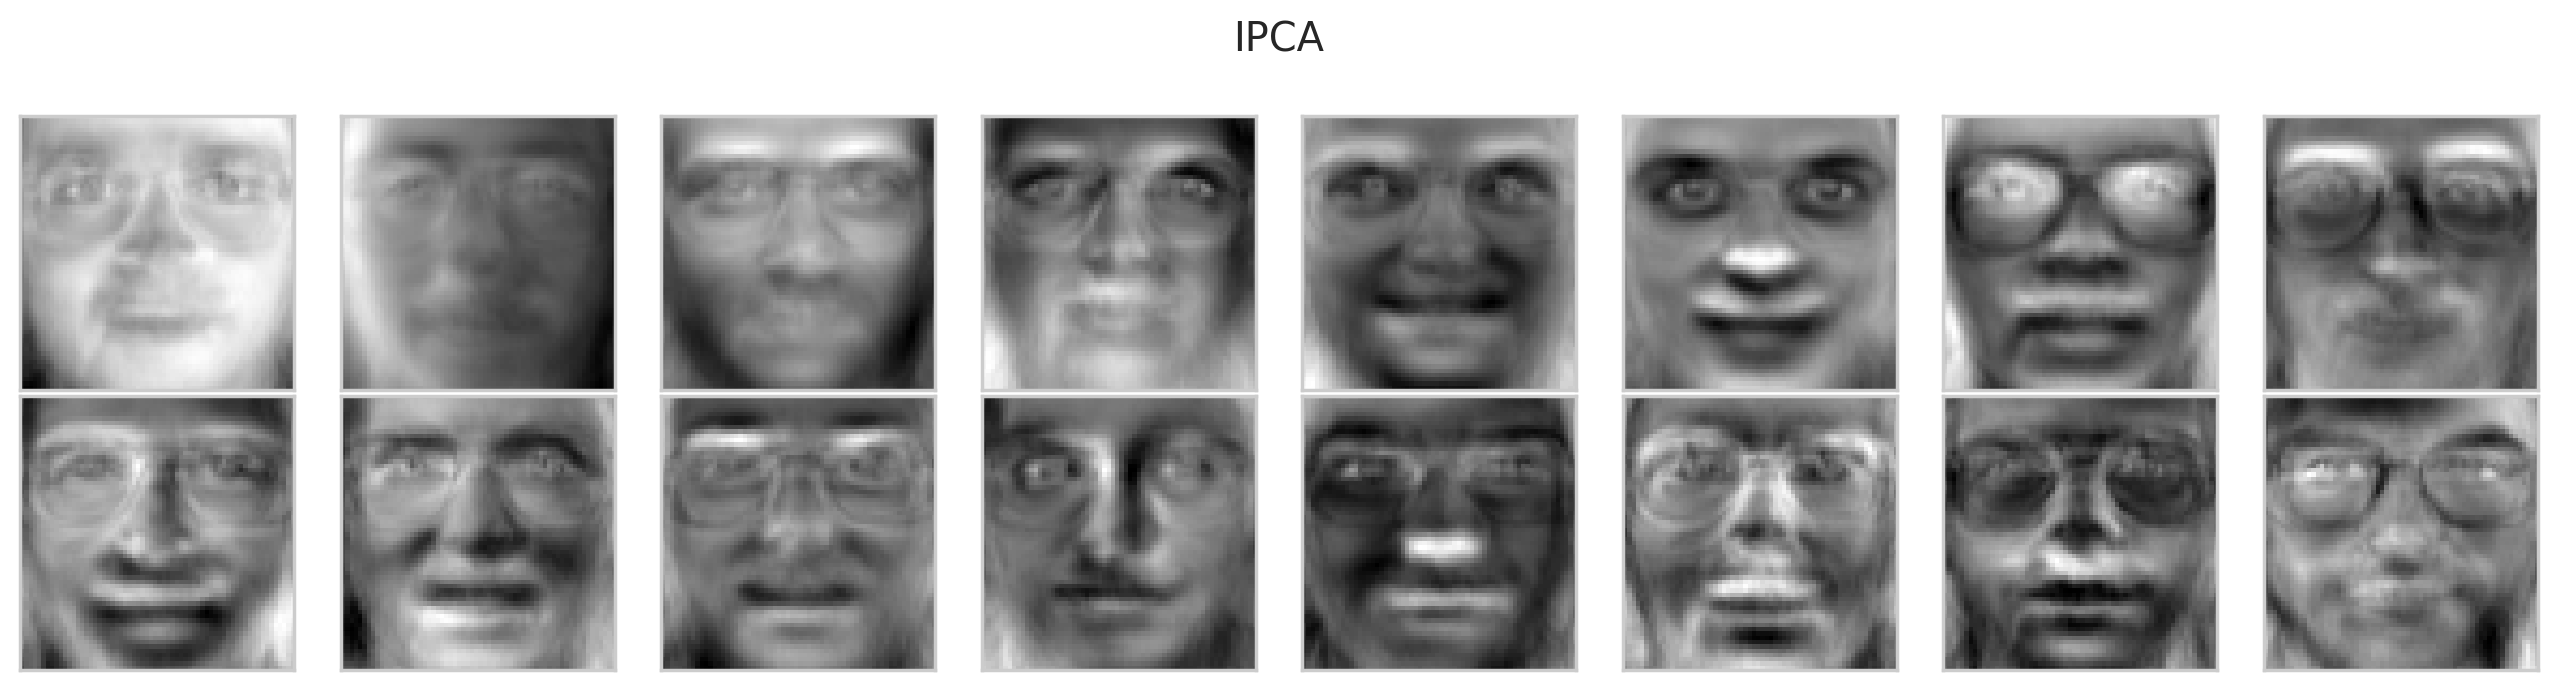

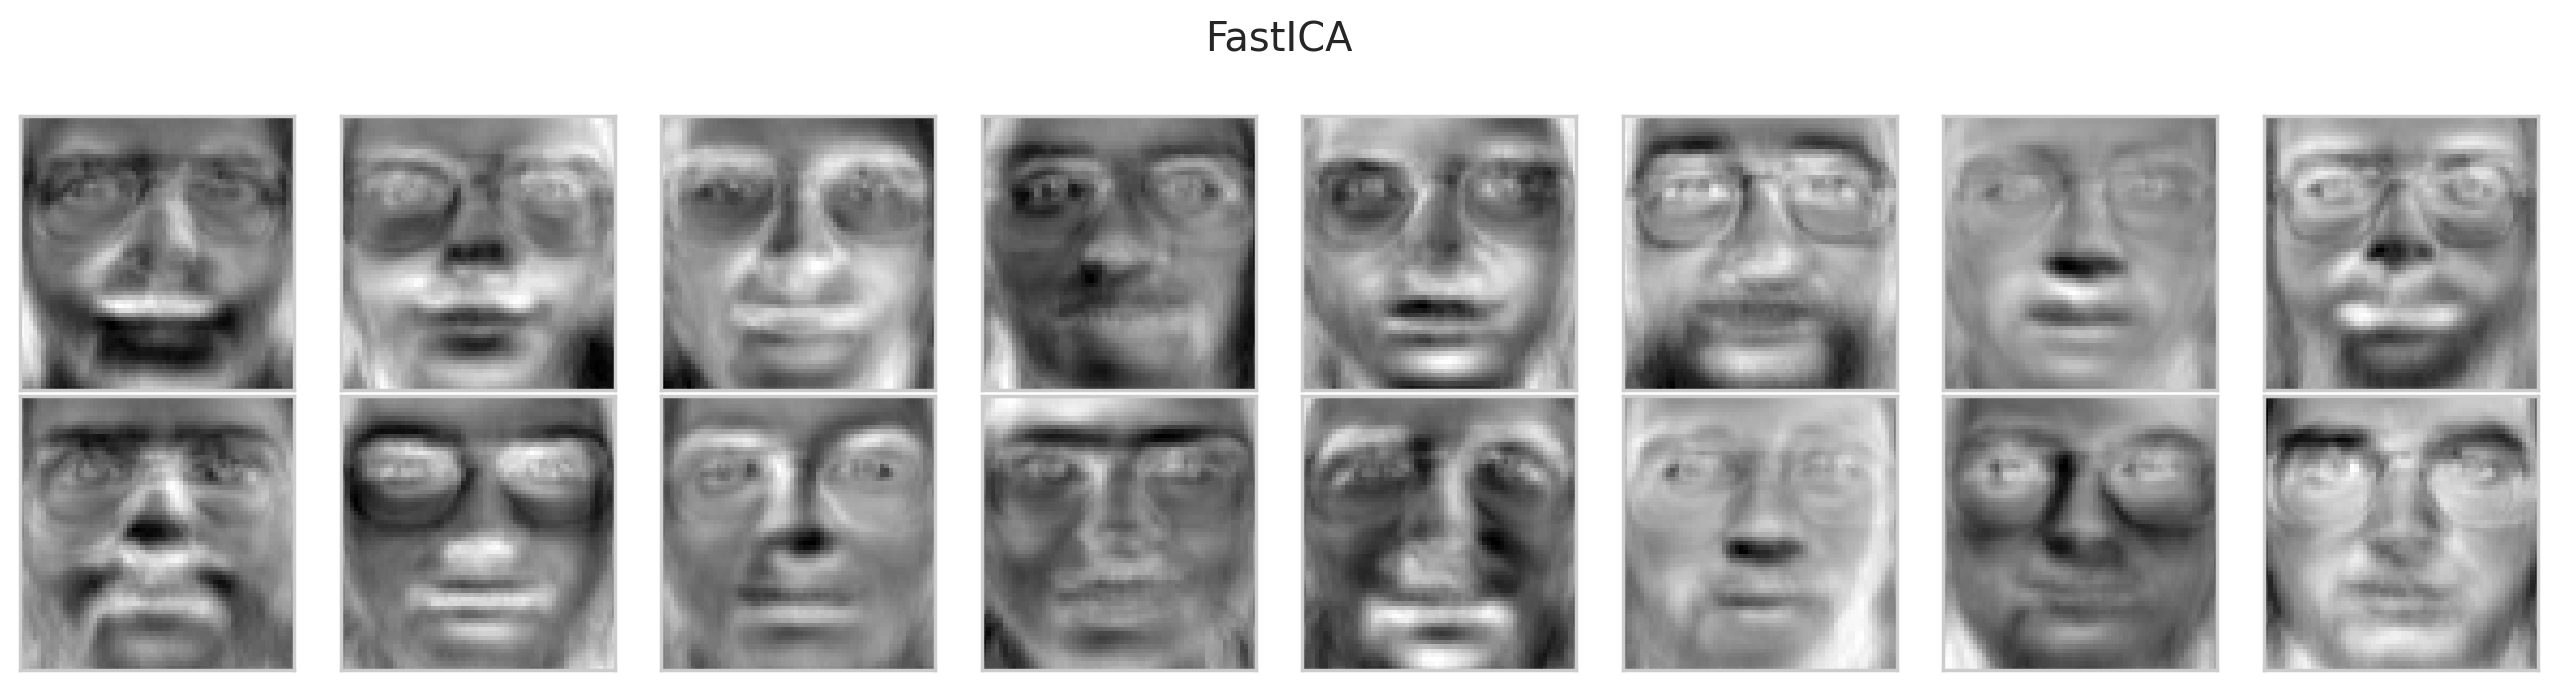

In [9]:
n_comp = 16
# Si la descarga estuviera bloqueada, sustituir por:  X = load_digits().data  (1797×64)

# (a) PCA EXACTA vs ALEATORIZADA: mismo resultado, distinto tiempo
t = time.perf_counter()
pca_full = PCA(n_comp, svd_solver='full').fit(X)
t_full = time.perf_counter() - t

t = time.perf_counter()
pca_rand = PCA(n_comp, svd_solver='randomized', random_state=RNG).fit(X)
t_rand = time.perf_counter() - t

dif = np.abs(pca_full.explained_variance_ratio_ - pca_rand.explained_variance_ratio_).max()
print(f"Tiempo exacta={t_full*1000:.0f} ms | aleatorizada={t_rand*1000:.0f} ms")
print(f"Máx. diferencia en varianza explicada: {dif:.2e}")   # ~1e-4 -> idénticas

# (b) PCA INCREMENTAL: por lotes, memoria constante
ipca = IncrementalPCA(n_components=n_comp, batch_size=50)
for i in range(0, X.shape[0], 50):
    ipca.partial_fit(X[i:i+50])     # se procesa lote a lote (como si no cupiera en RAM)
print(f"Var. explicada  exacta={pca_full.explained_variance_ratio_.sum():.4f} | "
      f"incremental={ipca.explained_variance_ratio_.sum():.4f}")   # casi iguales

# (c) FastICA: rasgos faciales LOCALIZADOS frente a las eigenfaces globales
ica = FastICA(n_components=n_comp, whiten='unit-variance',
              max_iter=500, random_state=RNG).fit(X)

# Representación de las soluciones
galeria(pca_full.components_, 'PCA — "eigenfaces" (rasgos globales)')
galeria(ipca.components_, 'IPCA')
galeria(ica.components_,      'FastICA')

**Lectura del resultado.** Conviene leerlo en dos planos, el numérico y el visual.

**Velocidad y fidelidad (números).** Con 16 componentes sobre las 400 caras (4096 píxeles cada una):

- *Exacta* ≈ **650 ms** frente a *aleatorizada* ≈ **490 ms**, y la diferencia entre las varianzas explicadas por una y otra es de apenas **5,7·10⁻⁷**: a efectos prácticos, **el mismo resultado**. La aproximación aleatoria no ha sacrificado calidad.
- La *incremental* explica **0,7248** de la varianza frente a **0,7310** de la exacta: una diferencia de seis milésimas. Procesando los datos por **mini-lotes** (sin tenerlos todos en RAM a la vez) reconstruye una solución **casi calcada** a la exacta.

Como este dataset cabe holgadamente en memoria, las ganancias de tiempo son modestas; el valor de estas variantes se dispara cuando los datos son enormes o llegan en *streaming* (lo veremos en el ejemplo génico).

**Qué "piezas" encuentra cada método (imágenes).** Aquí está la diferencia conceptual más reveladora:

- La **PCA** produce *eigenfaces*: plantillas de **cara completa**, rostros "fantasma" que capturan modos **globales** de variación (iluminación general, forma del rostro, las gafas como patrón difuso por toda la imagen). Cada componente mezcla **toda** la cara.
- **FastICA** descompone el rostro en **piezas locales**: parches concentrados en una zona concreta (un par de ojos, una boca, el contorno de unas gafas, una sombra lateral). En lugar de "caras medias", aísla los **rasgos independientes** que, combinados, componen cada rostro.

Es la diferencia "ordenar vs. separar voces" llevada a imágenes: la PCA ordena la variación global; el ICA aísla los componentes locales que actúan como fuentes independientes.

La PCA aleatorizada llega al mismo sitio que la exacta pero **más rápido** (diferencia en varianza explicada ~$10^{-4}$); la incremental reproduce casi calcado el resultado exacto; y mientras la PCA produce "caras promedio" (las *eigenfaces*, rasgos globales), ICA descompone el rostro en **piezas locales** (ojos, bocas, contornos), como si separase las "voces" que componen cada cara.

## 7.3. PCA aleatorizada en alta dimensión (datos expresión génica)

La "encuesta en vez de censo" se nota más cuanto más anchos son los datos, como tu dataset de cáncer colorrectal (147 × 54 676). Cargamos datos génicos del cuaderno anterior:

In [11]:
# Descarganos fichero comprimido a partir de su enlace de grive
id = "1lYXbPJpri9zmBDevtYCzY04CIiUs4HeR"
gdown.download(id=id, output="Colorectal.zip")
# Descomprimimos
local_zip = '/content/Colorectal.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/content')
zip_ref.close()

# Cargamos
colorectal = pd.read_csv('/content/Colorectal.csv')
# Eliminamos la variable que identifica la muestra
colorectal = colorectal.drop(columns=['samples'])
# Vemos las primeras cinco muestras
colorectal.head(5)

X_cancer = colorectal.drop(columns=['type'])
X_cancer

Downloading...
From (original): https://drive.google.com/uc?id=1lYXbPJpri9zmBDevtYCzY04CIiUs4HeR
From (redirected): https://drive.google.com/uc?id=1lYXbPJpri9zmBDevtYCzY04CIiUs4HeR&confirm=t&uuid=202b055a-f4ba-4f1c-91bb-01d0d3f9d026
To: /content/Colorectal.zip
100%|██████████| 62.7M/62.7M [00:00<00:00, 64.2MB/s]


,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,1431_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,9.734826,6.831690,5.555304,7.655082,3.226288,6.856453,6.457648,4.640385,5.064637,3.899915,...,13.444412,13.095456,14.032341,14.039828,10.068109,5.615495,7.689989,3.320701,3.561117,3.632902
1,9.606541,6.590221,5.468609,7.912497,3.328384,7.661894,6.251202,4.395160,6.395696,3.635589,...,12.436263,11.953700,13.711960,13.557925,9.131733,5.335406,6.850623,3.035550,3.567530,3.524690
2,10.261111,7.041191,6.024833,7.791206,3.351746,7.622168,5.980542,4.571086,6.451514,3.723189,...,12.719466,12.192479,13.804136,13.742535,10.128360,5.966523,8.133366,3.285989,3.460134,3.350227
3,9.866403,6.956243,6.319718,7.927724,3.428306,6.194461,6.421832,4.871198,5.174711,3.721124,...,12.460260,11.989959,13.717003,13.589126,9.492186,5.516504,7.487756,3.220194,3.384403,3.585887
4,9.318105,6.637016,5.590706,7.580309,3.249373,6.993910,5.829549,4.478472,6.621356,3.574915,...,12.387024,12.004889,13.764321,13.571701,9.170170,5.423915,7.215592,3.075573,3.518104,3.471065
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,10.637979,7.382793,5.642563,8.177714,3.518778,8.266974,6.905188,4.987845,5.442680,3.868973,...,12.117269,11.675262,13.295743,13.187937,10.512895,6.113882,8.514745,3.169916,3.606774,3.662049
143,10.966522,6.987055,6.042909,8.649539,3.640185,8.108340,6.645976,4.703452,5.099961,3.793830,...,12.072194,11.554180,13.273752,13.179464,9.559989,5.326715,7.277907,3.492220,3.799336,3.583645
144,10.270830,7.843320,5.725451,8.524955,3.720001,7.879431,6.888141,4.844136,6.838686,3.672367,...,12.170784,11.730818,13.441255,13.225796,9.806480,5.405663,7.591614,3.224599,3.543090,3.618311
145,10.499625,7.899510,5.387496,8.563266,3.512165,8.086939,6.711442,4.692948,8.750292,3.699706,...,12.090920,11.655675,13.388047,13.179203,10.888824,6.394414,8.788011,3.225351,3.578514,3.562569


In [12]:
# Tiempos de computación de ambos modelos
rng = np.random.RandomState(0)
t = time.perf_counter(); PCA(50, svd_solver='full').fit(X_cancer);                         t_full = time.perf_counter()-t
t = time.perf_counter(); PCA(50, svd_solver='randomized', random_state=0).fit(X_cancer);   t_rand = time.perf_counter()-t
print(f"Exacta={t_full:.3f}s | Aleatorizada={t_rand:.3f}s | Speedup ×{t_full/t_rand:.1f}")

Exacta=4.654s | Aleatorizada=2.162s | Speedup ×2.2


**Lectura del resultado.** Sobre los datos de expresión génica de cáncer colorrectal —**147 muestras × 54 676 genes**, una matriz extremadamente "ancha"— calcular 50 componentes tarda:

- *Exacta* ≈ **4,65 s** frente a *aleatorizada* ≈ **2,16 s** → un **×2,2 de aceleración**, obteniendo a efectos prácticos las mismas componentes.

Aquí se ve por qué la idea de "encuesta en vez de censo" rinde más cuanto **más anchos** son los datos: con decenas de miles de variables pero solo unas pocas componentes de interés (k=50), explorar todas las direcciones posibles es un derroche. La SVD aleatorizada lanza unas pocas **sondas aleatorias**, localiza el "barrio" donde se concentra la varianza y hace el trabajo fino sobre una matriz diminuta. Cuanto mayor es el cociente entre la dimensión total y el número de componentes pedidas, mayor es el ahorro —y en genómica, imagen o texto ese cociente es enorme.

> Recuerda fijar `random_state` para reproducibilidad. La ventaja **crece** si pides **pocas** componentes; si necesitaras casi todas, la aleatorización deja de compensar.

## 7.4. FastICA frente a PCA

El "problema del cóctel" en miniatura: dos señales independientes mezcladas que **solo ICA** sabe recuperar.

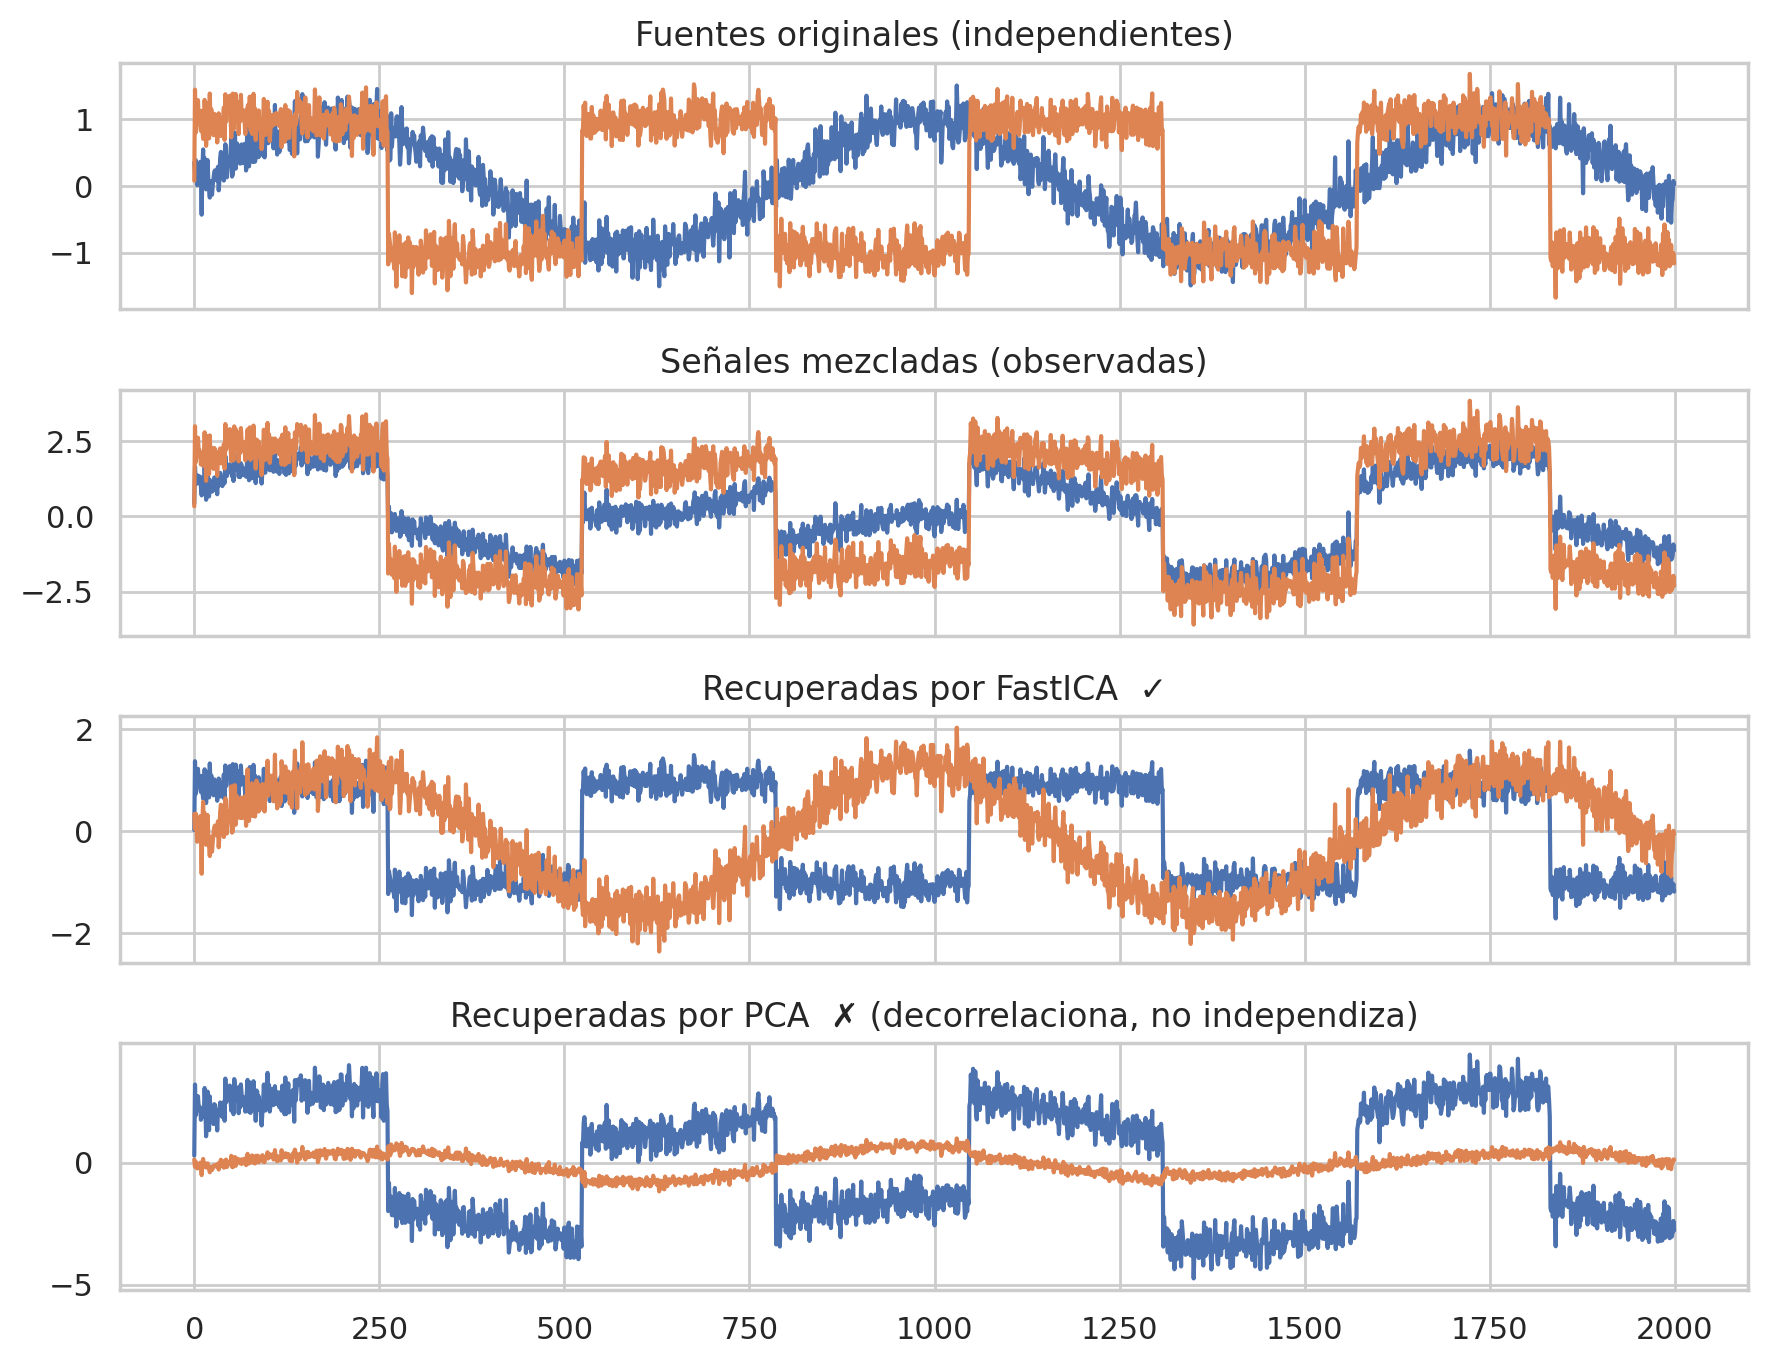

In [13]:
n = 2000
t = np.linspace(0, 8, n)
s1 = np.sin(2 * t)                 # señal senoidal
s2 = np.sign(np.sin(3 * t))        # señal cuadrada
S = np.c_[s1, s2] + 0.2 * rng.randn(n, 2)
A = np.array([[1, 1], [0.5, 2]])   # matriz de mezcla
Xmix = S @ A.T                     # señales observadas (mezcladas)

S_ica = FastICA(n_components=2, whiten='unit-variance', random_state=0).fit_transform(Xmix)
S_pca = PCA(n_components=2, random_state=0).fit_transform(Xmix)

fig, ax = plt.subplots(4, 1, figsize=(9, 7), sharex=True)
ax[0].plot(S);     ax[0].set_title('Fuentes originales (independientes)')
ax[1].plot(Xmix);  ax[1].set_title('Señales mezcladas (observadas)')
ax[2].plot(S_ica); ax[2].set_title('Recuperadas por FastICA  ✓')
ax[3].plot(S_pca); ax[3].set_title('Recuperadas por PCA  ✗ (decorrelaciona, no independiza)')
plt.tight_layout(); plt.show()

ICA reconstruye casi perfectamente las dos formas de onda originales; la PCA, que solo decorrelaciona, deja la senoidal y la cuadrada todavía enredadas. Es la diferencia entre "ordenar la sala" y "separar las voces".

**Lectura del resultado.** El gráfico tiene cuatro filas que se leen de arriba abajo como el "antes y después" del problema del cóctel:

1. **Fuentes originales (independientes):** las dos señales "puras" —una **senoidal** suave y una **cuadrada** que salta entre dos niveles—. Es lo que querríamos recuperar.
2. **Señales mezcladas (observadas):** lo único que en la práctica tendríamos. Cada "micrófono" capta una **combinación** de ambas y, a simple vista, ya no se distingue ni la senoidal ni la cuadrada.
3. **Recuperadas por FastICA ✓:** ICA reconstruye **las dos formas de onda originales** —vuelven a verse con claridad la cuadrada y la senoidal—, salvo por aquello que el método **no puede** determinar: el **orden** en que aparecen, su **signo** y su **escala/amplitud**. Recupera *la forma*, que es lo esencial.
4. **Recuperadas por PCA ✗:** la PCA solo decorrelaciona. Devuelve dos componentes ortogonales, pero **siguen mezcladas**: una concentra casi toda la amplitud y la otra queda casi plana; ninguna corresponde a una de las voces.

Es la demostración visual de la frase clave: **la PCA decorrelaciona; el ICA independiza.** Cuando el objetivo es *separar fuentes* (audio, EEG/MEG, sensores), la herramienta es ICA; cuando es *comprimir por varianza*, lo es la PCA.

## Síntesis de los experimentos

Los cuatro ejemplos, en conjunto, recorren los tres "puntos ciegos" de la PCA y muestran qué variante cura cada uno:

- **Estructura curva (círculos):** la PCA lineal no separa los anillos; la **Kernel PCA** los desenreda. *Lección: cuando la frontera es curva, el kernel adecuado convierte lo inseparable en separable.*
- **Tamaño y escala (caras y genes):** la **aleatorizada** y la **incremental** reproducen la PCA exacta (diferencias de ~10⁻⁴–10⁻⁷ en varianza explicada) con menos tiempo o menos memoria, y el ahorro crece con la anchura de los datos (×2,2 en los 54 676 genes). *Lección: para datos grandes o en streaming no hace falta renunciar a la PCA; basta su versión escalable.*
- **Fuentes mezcladas (caras y cóctel):** el **ICA** logra lo que la PCA no: separar voces (cóctel) y hallar rasgos locales independientes (caras). *Lección: si el objetivo es separar y no comprimir, la herramienta es ICA.*

En la práctica, la pregunta rara vez es "¿PCA o no?": es **qué versión de la idea de componentes** encaja con la forma de tus datos (curvos o no, grandes o no) y con tu objetivo (comprimir o separar).

# <font color="steelblue">8. Referencias y enlaces de interés</font>





Manuales

* Aurélien Géron (2019). Hands-On Machine Learning with Scikit-Learn, Keras, and Tensorflow: Concepts, Tools, and Techniques to Build Intelligent Systems. O’Reilly Media.

* Peters Morgan (2018). Data Analysis From Scratch With Python: Beginner Guide using Python, Pandas, NumPy, Scikit-Learn, IPython, TensorFlow and Matplotlib. AI Sciences LLC.

* Sebastian Raschka, Vahid Mirjalili (2017). Python Machine Learning: Machine Learning and Deep Learning with Python, scikit-learn, and TensorFlow. Packt Publishing.

* Julian Avila (2017). Scikit-Learn Cookbook: Over 80 Recipes for Machine Learning in Python With Scikit-Learn. Packt Publishing

Enlaces

* PCA con Python by Joaquín Amat Rodrigo, available under a Attribution 4.0 International (CC BY 4.0) at https://www.cienciadedatos.net/documentos/py19-pca-python.html

* https://colab.research.google.com/github/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/05.09-Principal-Component-Analysis.ipynb

